In [2]:
import pandas as pd
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder


import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
from torchvision import transforms
from torchvision.io import read_image
from torchvision.models.swin_transformer import swin_s
import torch.nn.functional as F 
from torchvision.utils import make_grid




print(torch.__version__)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


2.5.1+cu124
cuda:0


In [1]:
# import kagglehub

# # https://www.kaggle.com/datasets/joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20(Multiclass)

# # Download latest version
# path1 = kagglehub.dataset_download("joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20")

# # https://www.kaggle.com/datasets/nafin59/monkeypox-skin-lesion-dataset
# # Download latest version
# path2 = kagglehub.dataset_download("nafin59/monkeypox-skin-lesion-dataset")


# print("Path to dataset files:", path1)
# print("Path to dataset files:", path2)

Mounting files to /kaggle/input/monkeypox-skin-lesion-dataset...
Path to dataset files: /kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20
Path to dataset files: /kaggle/input/monkeypox-skin-lesion-dataset


 #                                 Loading Dataset

In [3]:
path = "/kaggle/input/monkeypox-skin-lesion-dataset/Augmented Images/Augmented Images"


data = {"imgpath": [] , "labels": [] }

category = os.listdir(path)
for folder in category:
    folderpath = os.path.join(path , folder)
    filelist = os.listdir(folderpath)
    for file in filelist:
        fpath = os.path.join(folderpath, file)
        data["imgpath"].append(fpath)
        data["labels"].append(folder)
      

df = pd.DataFrame(data) 


#Convert labels to numbers
lb = LabelEncoder()
df['encoded_labels'] = lb.fit_transform(df['labels'])


print("-------------Fetch files into a data frame-----------")
print(df)
print("-------------Path to an image file------------------")
print(df.loc[175]['imgpath']) 
print("-----------Number of images per category--------------")
print(df.labels.value_counts())  

-------------Fetch files into a data frame-----------
                                                imgpath               labels  \
0     /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
1     /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
2     /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
3     /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
4     /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
...                                                 ...                  ...   
3187  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   
3188  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   
3189  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   
3190  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   
3191  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox

#Split the Dataset into Train & Test

In [4]:
train_df, valid_df = train_test_split(df,  train_size= 0.80 , shuffle=True, random_state=124)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("#############Train Split###################")
print(train_df.head(5))
print(train_df.shape)
print("#############Test Split###################")
print(valid_df.head(5))
print(valid_df.shape)



#############Train Split###################
                                             imgpath               labels  \
0  /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
1  /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
2  /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
3  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   
4  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   

   encoded_labels  
0               1  
1               1  
2               1  
3               0  
4               0  
(2553, 3)
#############Test Split###################
                                             imgpath               labels  \
0  /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
1  /kaggle/input/monkeypox-skin-lesion-dataset/Au...     Others_augmented   
2  /kaggle/input/monkeypox-skin-lesion-dataset/Au...  Monkeypox_augmented   
3  /kaggle/i

# Applying Transforms to the Data

In [6]:
image_transforms = { 
    'train': transforms.Compose([
        transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]),
    'valid': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]),
    
}

# Train & Test Definition

In [7]:

class mpox_Dataset(Dataset):
    def __init__(self, img_data,transform=None):
        self.transform = transform
        self.img_data = img_data
        
    def __len__(self):
        return len(self.img_data)
    
    def __getitem__(self, index):
        img_name = self.img_data.loc[index]['imgpath']
        imge = Image.open(img_name)
        image = imge.resize((224,224))
        label = torch.tensor(self.img_data.loc[index]['encoded_labels'])
      
        if self.transform is not None:
            image = self.transform(image)
                        
        return image, label
        

training_data = mpox_Dataset(train_df, image_transforms['train'])
validatin_data = mpox_Dataset(valid_df, image_transforms['valid'])

print("okey")

okey


# DataLoader

In [8]:
train_batch_size = 200
val_batch_size = 100

train_dataloader = DataLoader(training_data, batch_size=train_batch_size, shuffle=True)
test_dataloader = DataLoader(validatin_data, batch_size=val_batch_size , shuffle=True)

print(">> Number of Train Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(train_dataloader.dataset) , train_batch_size , len(train_dataloader)))
print(">> Number of Validiation Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(test_dataloader.dataset) , val_batch_size , len(test_dataloader)))
onebatch = iter(train_dataloader)
train_features, train_labels = next(onebatch)
print("----------Batch Shape--------")
print(f"Feature batch shape: {train_features.size()}")
print("----------Labels Shape--------")
print(f"Labels batch shape: {train_labels.size()}")

>> Number of Train Data : 2553 -- Batch Size : 200 -- Number of Batch : 13 
>> Number of Validiation Data : 639 -- Batch Size : 100 -- Number of Batch : 7 
----------Batch Shape--------
Feature batch shape: torch.Size([200, 3, 224, 224])
----------Labels Shape--------
Labels batch shape: torch.Size([200])


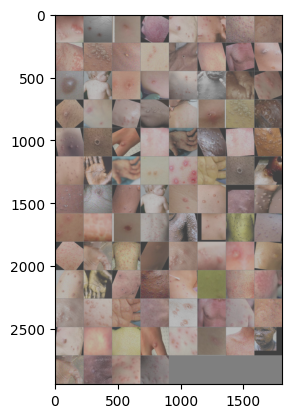

In [9]:
mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.25, 0.25, 0.25])
def imeshow(inp):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0,2)
    plt.imshow(inp)
    plt.show()

# Get a batch of training data
inputs, classes = next(iter(test_dataloader))

# Make a grid from batch
out = make_grid(inputs)
imeshow(out)

# Create a Model for learning

In [10]:
model = swin_s(pretrained=True)
for param in model.parameters(): #freeze model
    param.requires_grad = False

n_inputs = model.head.in_features
model.head = nn.Sequential(
    nn.Linear(n_inputs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 5)
)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)
optimizer = optim.AdamW(model.head.parameters(), lr=0.001)

print("okey")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_S_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/swin_s-5e29d889.pth" to /root/.cache/torch/hub/checkpoints/swin_s-5e29d889.pth
100%|██████████| 190M/190M [00:03<00:00, 56.0MB/s] 


okey


# Training

In [12]:
def train_model(model, optimizer, criterion , data_loader, device):

    model.train()
    running_loss = 0.0
    correct = 0
   
    
    for i, data in enumerate(data_loader):
        inputs , labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()       
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)        
        correct += (predicted == labels).sum().item()
        running_loss += loss.item() * inputs.size(0) 
        
    
    avg_train_loss = running_loss / len(data_loader.dataset)
    avg_train_acc = ( correct / len(data_loader.dataset) ) * 100
    print(">>> Train loss {} ---- Accuracy Train {} ".format(avg_train_loss, avg_train_acc))
   
    
    return avg_train_loss , avg_train_acc

# Validation

In [13]:
def test_model(model, criterion , data_loader, device):

    model.eval()    
  
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for i, data in enumerate(data_loader):
           
            inputs , labels = data            
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()                    
                                 
        avg_val_acc = ( correct / len(data_loader.dataset) ) * 100
        avg_val_loss = val_loss / len(data_loader.dataset)  
                     
        print(">>> Validation loss {} ---- Validation Accuracy {} ".format(avg_val_loss, avg_val_acc))  
         
    return avg_val_loss , avg_val_acc
 

# Running The Model

In [14]:
num_epochs = 25
history = {  "train_loss" : [] ,  "train_acc" : [] ,  "val_loss" : [] ,  "val_acc" : [] }
 
for epoch in range(num_epochs):  # loop over the dataset multiple times
    print("------------------ Training Epoch {} ------------------".format(epoch+1))
    T_loss , T_acc = train_model(model , optimizer , criterion, train_dataloader , device)
    V_loss , V_acc = test_model(model , criterion , test_dataloader, device)

    history["train_loss"].append(T_loss)
    history["train_acc"].append(T_acc)
    history["val_loss"].append(V_loss)
    history["val_acc"].append(V_acc)


------------------ Training Epoch 1 ------------------
>>> Train loss 0.657661792440971 ---- Accuracy Train 73.16882099490795 
>>> Validation loss 0.416807579089405 ---- Validation Accuracy 80.9076682316119 
------------------ Training Epoch 2 ------------------
>>> Train loss 0.3473783850996717 ---- Accuracy Train 84.41049745397572 
>>> Validation loss 0.3537664117760875 ---- Validation Accuracy 84.03755868544602 
------------------ Training Epoch 3 ------------------
>>> Train loss 0.29255089584024474 ---- Accuracy Train 87.50489620054837 
>>> Validation loss 0.3145363963499129 ---- Validation Accuracy 87.16744913928012 
------------------ Training Epoch 4 ------------------
>>> Train loss 0.2641995346667577 ---- Accuracy Train 89.0325107716412 
>>> Validation loss 0.3016598271745285 ---- Validation Accuracy 86.5414710485133 
------------------ Training Epoch 5 ------------------
>>> Train loss 0.2469813722199288 ---- Accuracy Train 89.62005483744613 
>>> Validation loss 0.2608318095

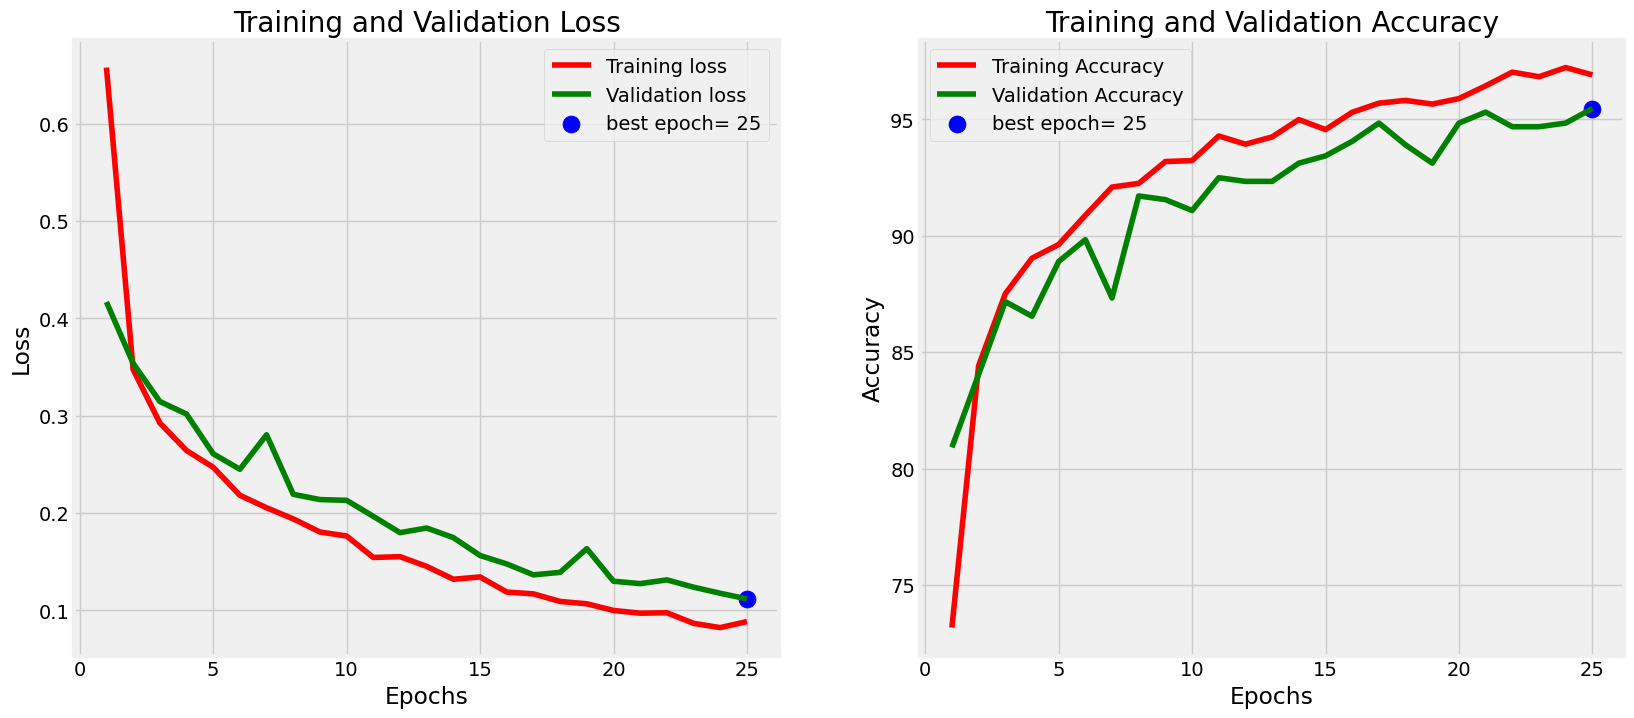

In [15]:
# Define needed variables
tr_acc = history["train_acc"]
tr_loss = history["train_loss"]
val_acc = history["val_acc"]
val_loss = history["val_loss"]


index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()